# Analyzing bilinear model performance

## Analyzing the threshold set for the model

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, auc
from sklearn.calibration import calibration_curve

In [46]:
# --- CONFIGURATION ---
# Path to the results CSV generated by your test script
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv"

In [47]:
# --- 1. LOAD DATA ---
print("Loading Predictions...")
df = pd.read_csv(RESULTS_PATH)

y_true = df['true_label'].values
y_scores = df['prob_similarity'].values # These are Probabilities (Sigmoid output)

print(f"Total Test Pairs: {len(df)}")
print(f"Positive Ratio: {np.mean(y_true):.2%}")

Loading Predictions...
Total Test Pairs: 4858
Positive Ratio: 50.00%


In [48]:
len(df)

4858

In [49]:
# --- 2. PRECISION-RECALL CURVE (The "Discovery" Map) ---
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

In [50]:
# Find the threshold that gives the best F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

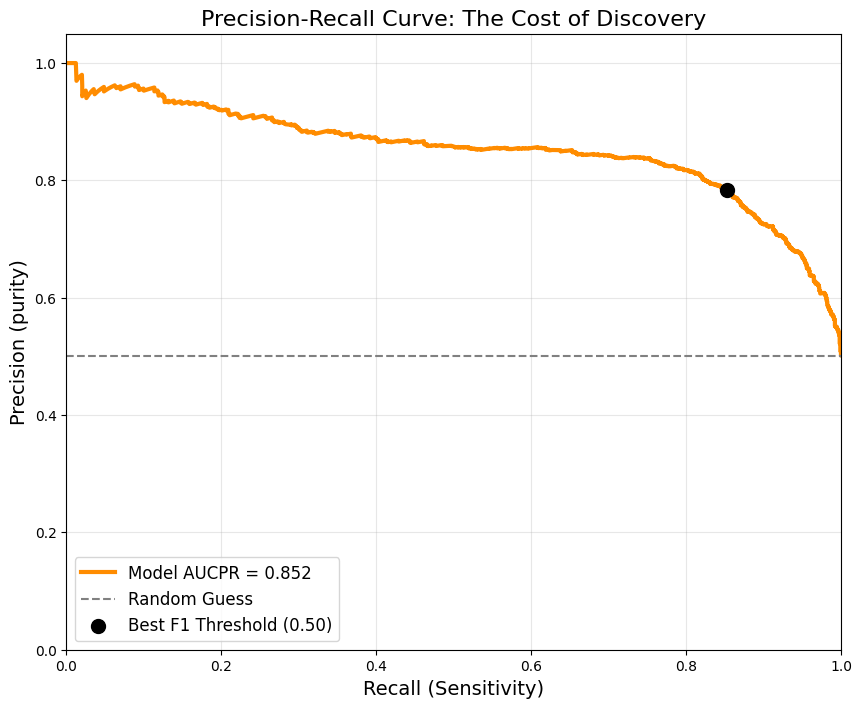

INTERPRETATION (PR Curve):
- Model AUCPR: 0.8515 (Closer to 1.0 is better)
- Optimal Threshold: 0.5003
  (If this is far from 0.5, your model is biased. If it's > 0.5, the model is conservative. If < 0.5, it's trigger-happy.)


In [51]:
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='darkorange', lw=3, label=f'Model AUCPR = {avg_precision:.3f}')
plt.plot([0, 1], [np.mean(y_true), np.mean(y_true)], linestyle='--', color='gray', label='Random Guess')

# Mark the Optimal Threshold
plt.scatter(recall[best_idx], precision[best_idx], marker='o', color='black', s=100, zorder=5, label=f'Best F1 Threshold ({best_thresh:.2f})')

plt.xlabel('Recall (Sensitivity)', fontsize=14)
plt.ylabel('Precision (purity)', fontsize=14)
plt.title('Precision-Recall Curve: The Cost of Discovery', fontsize=16)
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

print("INTERPRETATION (PR Curve):")
print(f"- Model AUCPR: {avg_precision:.4f} (Closer to 1.0 is better)")
print(f"- Optimal Threshold: {best_thresh:.4f}")
print("  (If this is far from 0.5, your model is biased. If it's > 0.5, the model is conservative. If < 0.5, it's trigger-happy.)")

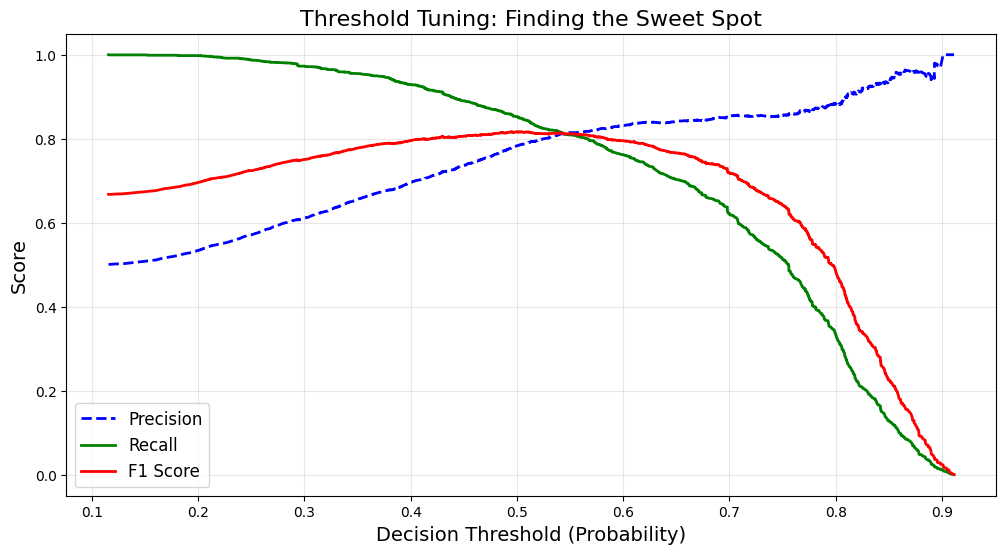

INTERPRETATION (Tuning):
- Look for the 'Cross-Over Point' where Precision and Recall meet.
- In Chemistry, False Positives (Bad Matches) are often worse than missing a match.
- You might want to pick a threshold slightly to the RIGHT of the peak F1 to ensure high Precision.


In [52]:
# --- 3. THRESHOLD TUNING (The "Operating Point") ---
# Plot F1, Precision, and Recall as a function of Threshold
plt.figure(figsize=(12, 6))

# We use the thresholds array from PR curve (it's sorted)
# Note: precision/recall arrays are 1 element longer than thresholds
plt.plot(thresholds, precision[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recall[:-1], "g-", label="Recall", linewidth=2)
plt.plot(thresholds, f1_scores[:-1], "r-", label="F1 Score", linewidth=2)

plt.xlabel("Decision Threshold (Probability)", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.title("Threshold Tuning: Finding the Sweet Spot", fontsize=16)
plt.legend(loc="best", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("INTERPRETATION (Tuning):")
print("- Look for the 'Cross-Over Point' where Precision and Recall meet.")
print("- In Chemistry, False Positives (Bad Matches) are often worse than missing a match.")
print("- You might want to pick a threshold slightly to the RIGHT of the peak F1 to ensure high Precision.")

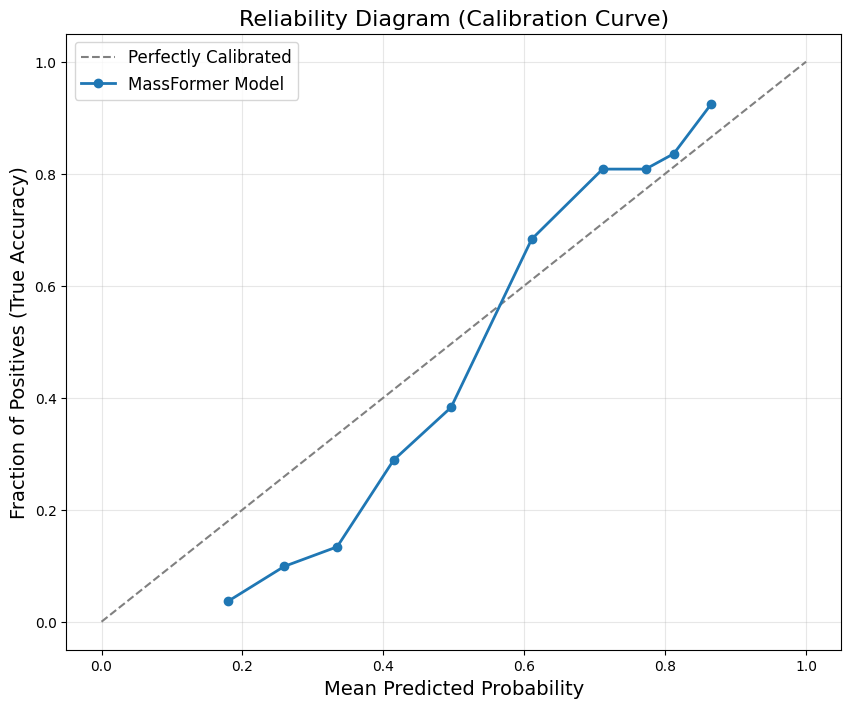

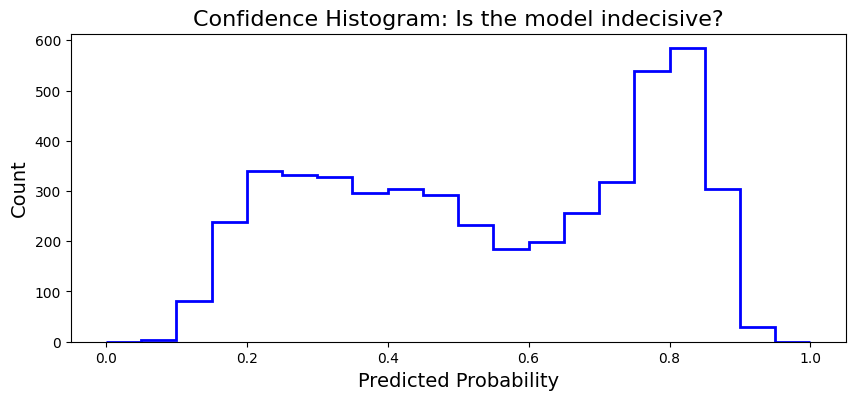

INTERPRETATION (Calibration):
- Curve BELOW the diagonal: The model is OVER-CONFIDENT. (It says 90% sure, but only 70% are right).
  -> Fix: Increase Mass Penalty weights or use Label Smoothing.
- Curve ABOVE the diagonal: The model is UNDER-CONFIDENT. (It says 60% sure, but 80% are actually right).
  -> Fix: Train longer or reduce regularization.
- Histogram: You want peaks at 0.0 and 1.0. A peak at 0.5 means the model is confused.


In [53]:
# --- 4. CALIBRATION CURVE (The "Trust" Map) ---
# Check if "80% confidence" actually means "80% correct"
prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10, strategy='quantile')

plt.figure(figsize=(10, 8))

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Model calibration
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='MassFormer Model')

plt.xlabel('Mean Predicted Probability', fontsize=14)
plt.ylabel('Fraction of Positives (True Accuracy)', fontsize=14)
plt.title('Reliability Diagram (Calibration Curve)', fontsize=16)
plt.legend(loc="best", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Histogram of Predicted Probabilities (Confidence Distribution)
plt.figure(figsize=(10, 4))
plt.hist(y_scores, range=(0, 1), bins=20, histtype="step", lw=2, color="blue")
plt.xlabel("Predicted Probability", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Confidence Histogram: Is the model indecisive?", fontsize=16)
plt.show()

print("INTERPRETATION (Calibration):")
print("- Curve BELOW the diagonal: The model is OVER-CONFIDENT. (It says 90% sure, but only 70% are right).")
print("  -> Fix: Increase Mass Penalty weights or use Label Smoothing.")
print("- Curve ABOVE the diagonal: The model is UNDER-CONFIDENT. (It says 60% sure, but 80% are actually right).")
print("  -> Fix: Train longer or reduce regularization.")
print("- Histogram: You want peaks at 0.0 and 1.0. A peak at 0.5 means the model is confused.")

## Analyzing the performance of the model on boundaries

In [54]:
from scipy.stats import pearsonr, spearmanr

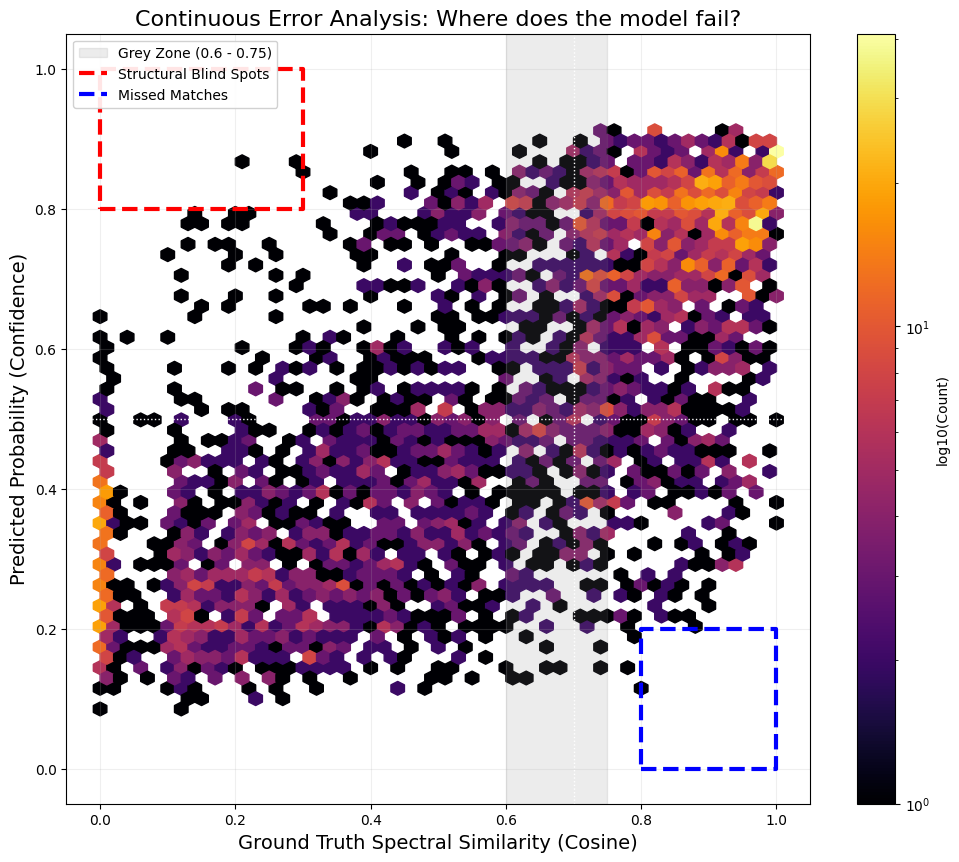

ALIGNMENT METRICS:
- Pearson Correlation:  0.7261 (Linear alignment)
- Spearman Correlation: 0.7136 (Rank alignment - often more important)
  (A low correlation means the model is guessing randomly within class labels.)

--- TOP 5 'STRUCTURAL BLIND SPOTS' (High Confidence FPs) ---
Good news! No extreme blind spots found.

--- TOP 5 'GREY ZONE' FAILURES ---
Total Pairs in Grey Zone: 711
Error Rate in Grey Zone:  42.05%

Sample Grey Zone Errors:
                name_main              name_sub  cosine_similarity  \
66   MassSpecGymID0003073  MassSpecGymID0049409           0.713722   
118  MassSpecGymID0078203  MassSpecGymID0078834           0.671762   
120  MassSpecGymID0211557  MassSpecGymID0231978           0.706099   
135  MassSpecGymID0020971  MassSpecGymID0053860           0.683481   
155  MassSpecGymID0056029  MassSpecGymID0109777           0.710030   

     prob_similarity  true_label  
66          0.469530         1.0  
118         0.669118         0.0  
120         0.300271      

In [55]:
# Ensure we have Ground Truth Similarity
if 'cosine_similarity' not in df.columns:
    print("Error: 'cosine_similarity' column missing. This analysis requires continuous ground truth.")
else:
    # --- 2. THE SCATTER PLOT (Probability vs Truth) ---
    plt.figure(figsize=(12, 10))
    
    # We use a Hexbin plot because scatter plots get messy with thousands of points
    # It shows density: Darker hexagons = More pairs
    hb = plt.hexbin(
        x=df['cosine_similarity'], 
        y=df['prob_similarity'], 
        gridsize=50, 
        cmap='inferno', 
        mincnt=1,
        bins='log' # Log scale for color intensity
    )
    cb = plt.colorbar(hb, label='log10(Count)')
    
    # --- ADD DIAGNOSTIC ZONES ---
    # Zone A: The "Grey Zone" (Hardest pairs)
    # Ground Truth 0.6 to 0.75
    plt.axvspan(0.6, 0.75, color='gray', alpha=0.15, label='Grey Zone (0.6 - 0.75)')
    
    # Zone B: High-Confidence False Positives (Blind Spots)
    # Truth < 0.3 (Very different) AND Prob > 0.8 (Model is sure they match)
    # We draw a red box outline
    plt.plot([0.0, 0.3, 0.3, 0.0, 0.0], [0.8, 0.8, 1.0, 1.0, 0.8], 
             color='red', linewidth=3, linestyle='--', label='Structural Blind Spots')
    
    # Zone C: High-Confidence False Negatives (Missed Isomers?)
    # Truth > 0.8 (Identical) AND Prob < 0.2 (Model says "No way")
    plt.plot([0.8, 1.0, 1.0, 0.8, 0.8], [0.0, 0.0, 0.2, 0.2, 0.0], 
             color='blue', linewidth=3, linestyle='--', label='Missed Matches')

    # Reference Lines
    plt.axhline(0.5, color='white', linestyle=':', linewidth=1) # Model Decision Boundary
    plt.axvline(0.7, color='white', linestyle=':', linewidth=1) # Dataset Threshold
    
    plt.xlabel("Ground Truth Spectral Similarity (Cosine)", fontsize=14)
    plt.ylabel("Predicted Probability (Confidence)", fontsize=14)
    plt.title("Continuous Error Analysis: Where does the model fail?", fontsize=16)
    plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    plt.grid(True, alpha=0.2)
    plt.show()

    # --- 3. CORRELATION METRICS ---
    # How well does the model's "Confidence" track with "Actual Similarity"?
    p_corr, _ = pearsonr(df['cosine_similarity'], df['prob_similarity'])
    s_corr, _ = spearmanr(df['cosine_similarity'], df['prob_similarity'])
    
    print("ALIGNMENT METRICS:")
    print(f"- Pearson Correlation:  {p_corr:.4f} (Linear alignment)")
    print(f"- Spearman Correlation: {s_corr:.4f} (Rank alignment - often more important)")
    print("  (A low correlation means the model is guessing randomly within class labels.)")

    # --- 4. EXTRACTING THE CULPRITS ---
    print("\n--- TOP 5 'STRUCTURAL BLIND SPOTS' (High Confidence FPs) ---")
    # Pairs where they look different (Sim < 0.3) but model loves them (Prob > 0.9)
    blind_spots = df[
        (df['cosine_similarity'] < 0.3) & 
        (df['prob_similarity'] > 0.9)
    ].sort_values('prob_similarity', ascending=False).head(5)
    
    if len(blind_spots) > 0:
        for idx, row in blind_spots.iterrows():
            print(f"1. {row['name_main']} vs {row['name_sub']}")
            print(f"   Truth: {row['cosine_similarity']:.4f} | Model Conf: {row['prob_similarity']:.4f}")
            print("   (Check these structures: Do they have matching peaks but different backbones?)")
    else:
        print("Good news! No extreme blind spots found.")
    
    print("\n--- TOP 5 'GREY ZONE' FAILURES ---")
    # Pairs in the 0.6-0.75 range where the model was WRONG
    # We define "Wrong" as being on the incorrect side of 0.5 compared to the label
    grey_zone = df[(df['cosine_similarity'] >= 0.6) & (df['cosine_similarity'] <= 0.75)].copy()
    
    # False Positives in Grey Zone (Truth < 0.7 but Model > 0.5)
    # Assuming your dataset cutoff was 0.7. If Truth is 0.65, label is 0.
    # If model predicts 0.9, it's an error.
    grey_errors = grey_zone[grey_zone['true_label'] != grey_zone['predicted_label']]
    
    print(f"Total Pairs in Grey Zone: {len(grey_zone)}")
    print(f"Error Rate in Grey Zone:  {len(grey_errors) / len(grey_zone):.2%}")
    
    if len(grey_errors) > 0:
        print("\nSample Grey Zone Errors:")
        print(grey_errors[['name_main', 'name_sub', 'cosine_similarity', 'prob_similarity', 'true_label']].head())

## Analyzing model performance according mass difference bin

In [56]:
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix

In [57]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv"
SPEC_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

In [58]:
# --- 1. LOAD & PREPARE ---
print("Loading Results...")
df_res = pd.read_csv(RESULTS_PATH)
df_spec = pd.read_pickle(SPEC_META_PATH)

# Helper: Load Precursor Masses
spec2mz = dict(zip(df_spec['spec_id'], df_spec['prec_mz']))

# Re-calculate Mass Diff
df_res['mz_A'] = df_res['name_main'].map(spec2mz)
df_res['mz_B'] = df_res['name_sub'].map(spec2mz)
df_res['mass_diff'] = abs(df_res['mz_A'] - df_res['mz_B'])

Loading Results...


In [59]:
# --- 2. APPLY YOUR CUSTOM REGIMES ---
# We use pd.cut with your exact boundaries
bins = [0.0001, 0.01, 1.0, 10.0, 50.0, 100.0, 100000.0]
labels = [
    "0. Exact Isomers (0 Da)", 
    "1. Isobaric (< 1 Da)", 
    "2. Tiny (1-10 Da)", 
    "3. Medium (10-50 Da)", 
    "4. Large (50-100 Da)", 
    "5. Huge (>100 Da)"
]

df_res['Mass_Regime'] = pd.cut(df_res['mass_diff'], bins=bins, labels=labels)

print("Distribution by New Regimes:")
print(df_res['Mass_Regime'].value_counts().sort_index())

Distribution by New Regimes:
Mass_Regime
0. Exact Isomers (0 Da)      47
1. Isobaric (< 1 Da)         36
2. Tiny (1-10 Da)           353
3. Medium (10-50 Da)       1757
4. Large (50-100 Da)       1026
5. Huge (>100 Da)          1119
Name: count, dtype: int64


In [60]:
# --- 3. CALCULATE METRICS PER BIN ---
results = []

for regime in labels:
    subset = df_res[df_res['Mass_Regime'] == regime]
    
    if len(subset) == 0: 
        print(f"Skipping empty regime: {regime}")
        continue
    
    y_true = subset['true_label']
    y_pred = subset['predicted_label']
    
    # Metrics
    if len(y_true.unique()) > 1:
        f1 = f1_score(y_true, y_pred)
        mcc = matthews_corrcoef(y_true, y_pred)
    else:
        f1 = 0.0; mcc = 0.0 # Handle edge cases
        
    # False Positive Rate (The "Cheating" Detector)
    # FPR = FP / (FP + TN)
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    except:
        tn, fp, fn, tp = 0, 0, 0, 0
        fpr = 0.0
    
    results.append({
        'Regime': regime,
        'Count': len(subset),
        'MCC (Quality)': mcc,
        'FPR (False Alarm)': fpr,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

df_metrics = pd.DataFrame(results)

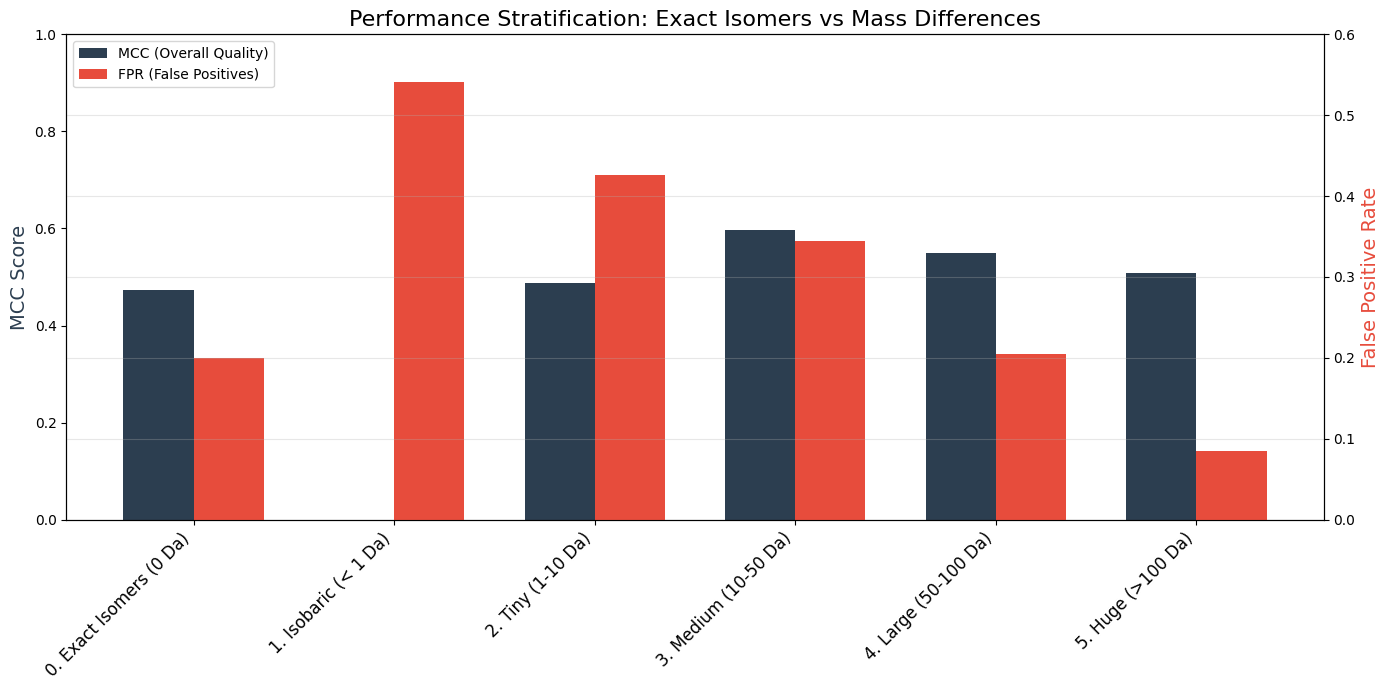

In [61]:
# --- 4. VISUALIZATION: THE PERFORMANCE CLIFF ---
fig, ax1 = plt.subplots(figsize=(14, 7))

x = np.arange(len(df_metrics))
width = 0.35

# Bar 1: MCC (Blue) -> Higher is Better
ax1.bar(x - width/2, df_metrics['MCC (Quality)'], width, label='MCC (Overall Quality)', color='#2c3e50')
ax1.set_ylabel('MCC Score', color='#2c3e50', fontsize=14)
ax1.set_ylim(0, 1.0)

# Bar 2: FPR (Red) -> Lower is Better
ax2 = ax1.twinx()
ax2.bar(x + width/2, df_metrics['FPR (False Alarm)'], width, label='FPR (False Positives)', color='#e74c3c')
ax2.set_ylabel('False Positive Rate', color='#e74c3c', fontsize=14)
ax2.set_ylim(0, 0.6) # Zoom into the error range

ax1.set_xticks(x)
ax1.set_xticklabels(df_metrics['Regime'], rotation=45, ha='right', fontsize=12)
ax1.set_title("Performance Stratification: Exact Isomers vs Mass Differences", fontsize=16)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


--- DEEP DIVE: 0. Exact Isomers (0 Da) ---


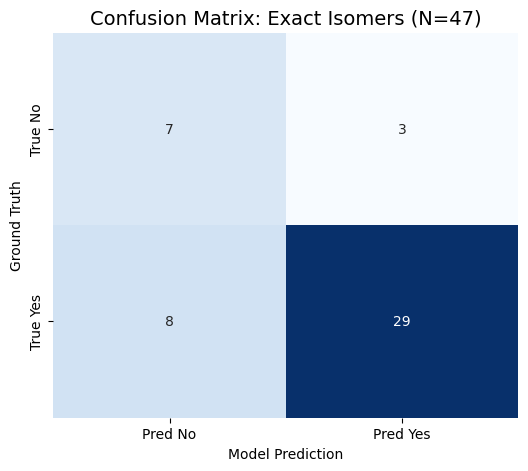

Accuracy on Exact Isomers: 76.60%
Interpretation:
- True Negatives (0,0): Model correctly identified Stereoisomers (Same Mass, Different Structure).
- False Positives (0,1): Model failed to distinguish Stereoisomers (The 'Hardest' Error).


In [25]:
# --- 5. DEEP DIVE: THE "EXACT ISOMER" MATRIX ---
# Specifically look at Bin 0
print("\n--- DEEP DIVE: 0. Exact Isomers (0 Da) ---")
iso_subset = df_res[df_res['Mass_Regime'] == "0. Exact Isomers (0 Da)"]

if len(iso_subset) > 0:
    cm = confusion_matrix(iso_subset['true_label'], iso_subset['predicted_label'], labels=[0,1])
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['True No', 'True Yes'])
    plt.title(f"Confusion Matrix: Exact Isomers (N={len(iso_subset)})", fontsize=14)
    plt.ylabel("Ground Truth")
    plt.xlabel("Model Prediction")
    plt.show()
    
    # Calculate Specific Accuracy for Isomers
    acc_iso = (cm[0,0] + cm[1,1]) / cm.sum()
    print(f"Accuracy on Exact Isomers: {acc_iso:.2%}")
    print("Interpretation:")
    print("- True Negatives (0,0): Model correctly identified Stereoisomers (Same Mass, Different Structure).")
    print("- False Positives (0,1): Model failed to distinguish Stereoisomers (The 'Hardest' Error).")
else:
    print("No Exact Isomers found in Test Set.")

In [26]:
df_metrics["FPR (False Alarm)"].mean()

0.31236126574905565

## Analyze the latent space of the geometric embeddings from the Mass Former Encoder

In [20]:
import torch
import yaml
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from tqdm import tqdm
import os
import sys
from pathlib import Path

%matplotlib inline

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
# --- 2. CONFIGURATION (Edit your paths here) ---
class Args:
    # PATHS
    test_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
    mol_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
    
    # CONFIGS
    template_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"  # Update path relative to notebook
    custom_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"        # Update path relative to notebook
    
    # MODELS
    checkpoint_path = "/data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl"  # Path to initial encoder weights
    binary_model_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/vicreg/best_focal_model_supcon.pth" # Path to your TRAINED model
    
    output_dir = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/mass_gate/"
    gpu_id = 0
    batch_size = 32

args = Args()

In [22]:
# --- SETUP PATHS ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [23]:
cwd

PosixPath('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor')

In [24]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [25]:
# --- 4. IMPORT MODEL & LOADER ---
try:
    # Assuming classifier_siamesemodel_new.py is in your 'model' folder
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
    
    def merge_configs(base, custom):
        import copy
        merged = copy.deepcopy(base)
        for k, v in custom.items():
            if isinstance(v, dict) and k in merged:
                merged[k] = merge_configs(merged[k], v)
            else:
                merged[k] = v
        return merged
        
    print("✅ Modules imported successfully.")
except ImportError as e:
    print(f"❌ Error importing modules: {e}")
    print("Check your sys.path inserts above.")

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:207: FutureWarning: `to

✅ Modules imported successfully.


In [26]:
# --- 4. VISUALIZATION FUNCTION ---
def visualize_latent(args):
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    print(f"--- DUAL LATENT SPACE ANALYSIS ---")

    # A. LOAD DATA
    print("Loading Test Data...")
    ds = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    
    # Get Metadata Dim
    try: spec_meta_dim = ds[0][2].shape[1]
    except: spec_meta_dim = 68
    
    # Pre-fetch precursor masses for coloring the Chemical Space plot
    # (We want to see if the model clusters by mass/chemistry)
    print("Caching Precursor Masses...")
    spec2mz = ds.spec_lookup['prec_mz'].to_dict()
    
    loader = torch.utils.data.DataLoader(ds, batch_size=args.batch_size, shuffle=False, collate_fn=binary_collate_fn, num_workers=4)

    # B. LOAD MODEL
    print(f"Loading Model...")
    with open(args.template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: custom_config = yaml.safe_load(f)
    full_config = merge_configs(template_config, custom_config)

    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)
    
    state_dict = torch.load(args.binary_model_path, map_location=device)
    if 'state_dict' in state_dict: state_dict = state_dict['state_dict']
    model.load_state_dict(state_dict)
    model.eval()

    # C. EXTRACTION LOOP
    print("Extracting Embeddings...")
    diff_vectors = []  # |hA - hB|
    raw_vectors = []   # hA
    labels = []
    preds = []
    mass_A_vals = []   # Actual Mass of Molecule A
    
    MAX_SAMPLES = 5000 
    count = 0
    
    # Need to access dataset indices to map back to Spec IDs for Mass
    # We'll rely on the order being preserved since shuffle=False
    start_idx = 0
    
    with torch.no_grad():
        for batch_A, batch_B, batch_meta, batch_md, batch_y in tqdm(loader):
            # Move to GPU
            for k in batch_A: batch_A[k] = batch_A[k].to(device)
            for k in batch_B: batch_B[k] = batch_B[k].to(device)
            batch_meta = batch_meta.to(device)
            batch_md = batch_md.to(device)
            
            # 1. Embeddings
            h_A = model.encoder({'gf_v2_data': batch_A})
            h_B = model.encoder({'gf_v2_data': batch_B})
            
            # 2. Difference (Interaction)
            diff = torch.abs(h_A - h_B)
            
            # 3. Prediction
            logits = model(batch_A, batch_B, batch_meta, batch_md).squeeze()
            batch_preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
            
            # Store
            diff_vectors.append(diff.cpu().numpy())
            raw_vectors.append(h_A.cpu().numpy())
            labels.append(batch_y.numpy())
            preds.append(batch_preds)
            
            # Get Mass of Molecule A for coloring
            # (We reconstruct indices roughly based on batch size)
            current_batch_size = len(batch_y)
            batch_indices = range(start_idx, start_idx + current_batch_size)
            for i in batch_indices:
                try:
                    name_main = ds.pairs_df.iloc[i]['name_main']
                    mass_A_vals.append(spec2mz.get(name_main, 0.0))
                except:
                    mass_A_vals.append(0.0)
            start_idx += current_batch_size
            
            count += current_batch_size
            if count >= MAX_SAMPLES: break

    # D. UMAP PROJECTIONS
    X_diff = np.vstack(diff_vectors)
    X_raw = np.vstack(raw_vectors)
    y_true = np.concatenate(labels)
    y_pred = np.concatenate(preds)
    mass_A = np.array(mass_A_vals)

    print("Running UMAP 1: Interaction Space (|hA - hB|)...")
    umap_diff = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(X_diff)
    
    print("Running UMAP 2: Chemical Space (hA)...")
    umap_raw = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(X_raw)

    # E. PLOTTING
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # 1. Interaction Space (Ground Truth)
    # Goal: See if Matches (Green) are separated from Non-Matches (Red)
    sns.scatterplot(x=umap_diff[:,0], y=umap_diff[:,1], hue=y_true, 
                    palette={0: 'red', 1: 'green'}, s=15, alpha=0.5, ax=axes[0])
    axes[0].set_title("1. Interaction Space\n(Separation of Matches vs Non-Matches)", fontsize=14)
    axes[0].legend(title='Ground Truth')

    # 2. Interaction Space (Error Analysis)
    # Goal: See where the False Positives (Orange) are located
    # Create Error Labels
    error_types = []
    for t, p in zip(y_true, y_pred):
        if t==1 and p==1: error_types.append('TP')
        elif t==0 and p==0: error_types.append('TN')
        elif t==0 and p==1: error_types.append('False Positive')
        elif t==1 and p==0: error_types.append('False Negative')
    
    sns.scatterplot(x=umap_diff[:,0], y=umap_diff[:,1], hue=error_types, 
                    palette={'TP':'lightgray', 'TN':'lightgray', 'False Positive':'orange', 'False Negative':'blue'}, 
                    s=20, alpha=0.6, ax=axes[1])
    axes[1].set_title("2. Interaction Errors\n(Where are the False Positives?)", fontsize=14)

    # 3. Chemical Space (Identity)
    # Goal: See if h_A clusters by Precursor Mass (Chemistry)
    # Ideally, we see a gradient of colors, not a random mix.
    sc = axes[2].scatter(umap_raw[:,0], umap_raw[:,1], c=mass_A, cmap='viridis', s=15, alpha=0.5)
    axes[2].set_title("3. Chemical Space (h_A)\n(Colored by Precursor Mass)", fontsize=14)
    plt.colorbar(sc, ax=axes[2], label='Precursor Mass (Da)')

    plt.tight_layout()
    os.makedirs(args.output_dir, exist_ok=True)
    plt.savefig(os.path.join(args.output_dir, "dual_latent_analysis.png"), dpi=150)
    plt.show()

--- DUAL LATENT SPACE ANALYSIS ---
Loading Test Data...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...


Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Caching Precursor Masses...
Loading Model...
Loading encoder weights from /data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active


/tmp/ipykernel_1966087/768168115.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(args.binary_model_path, map_location=device)


Extracting Embeddings...


100%|██████████| 152/152 [00:07<00:00, 20.46it/s]
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP 1: Interaction Space (|hA - hB|)...
Running UMAP 2: Chemical Space (hA)...


/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


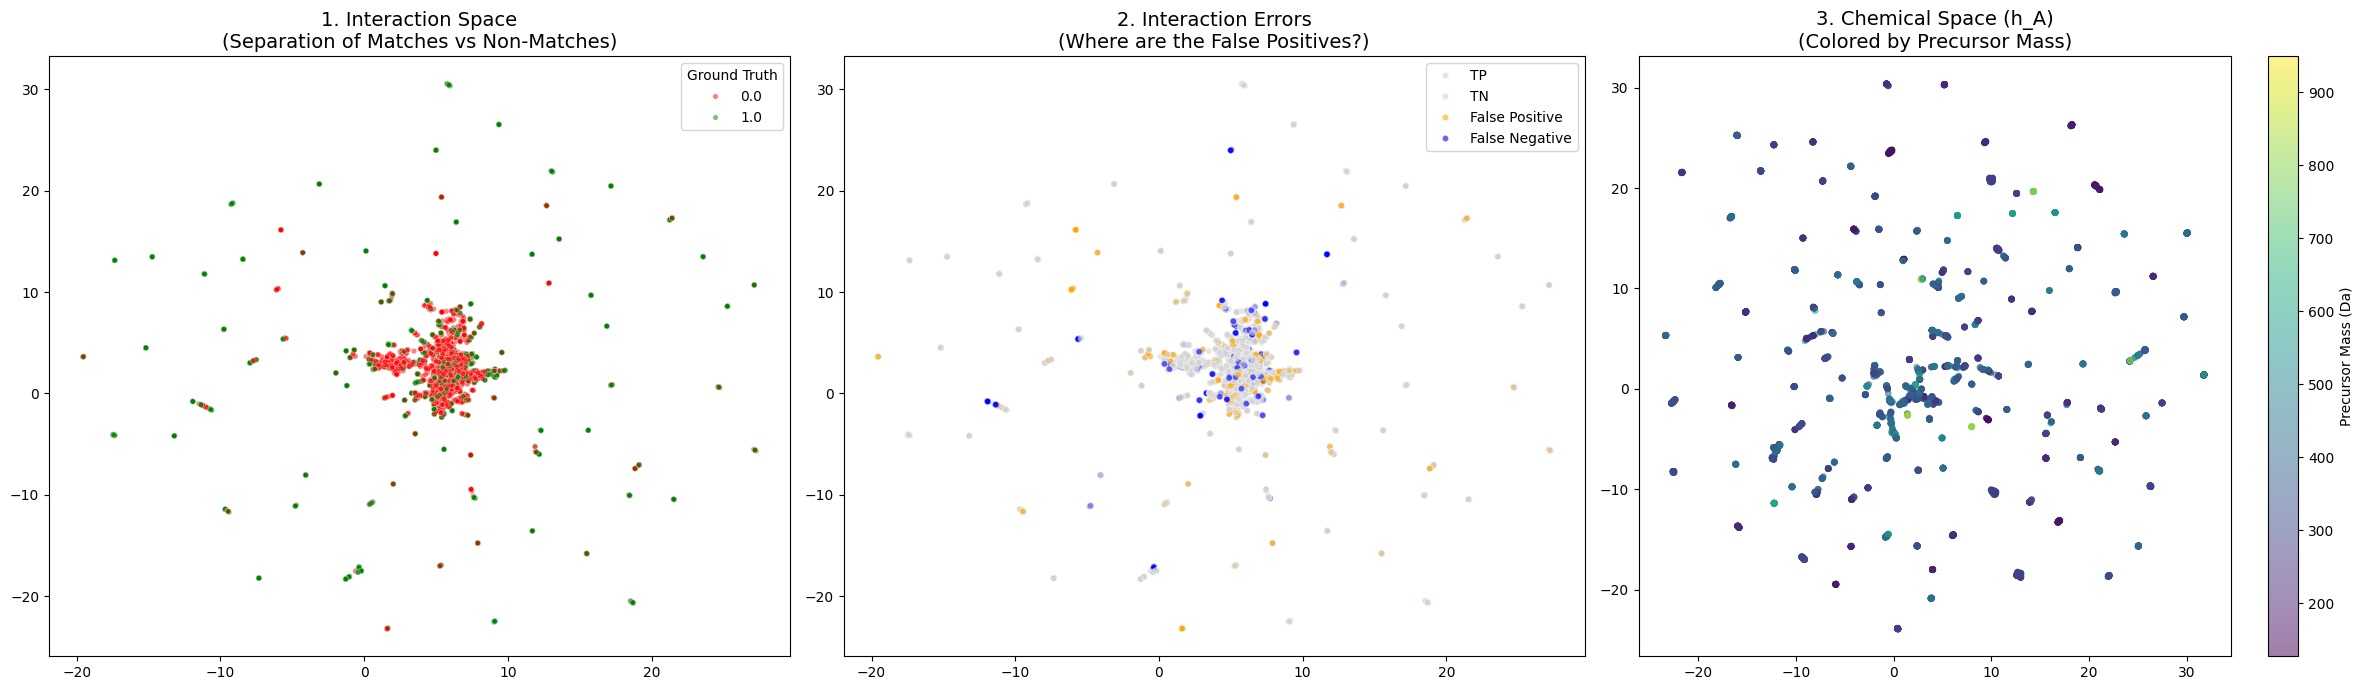

In [27]:
# --- 6. RUN ---
visualize_latent(args)

In [28]:
# --- 1. IMPORTS & SETUP ---
import torch
import torch.nn.functional as F
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os
import sys
from pathlib import Path

%matplotlib inline

In [29]:
# --- 2. CONFIGURATION (Reuse Args from previous cells) ---
# Ensure 'args' is defined (e.g. from the previous UMAP cell)
if 'args' not in locals():
    print("⚠️ Please define 'args' class first (copy from UMAP cell).")

In [30]:
# --- 3. METRIC FUNCTIONS ---
def compute_alignment(x, y, alpha=2):
    """
    Alignment: Expected distance between positive pairs.
    L_align = E[||x - y||^2]
    """
    return (x - y).norm(p=2, dim=1).pow(alpha).mean()

def compute_uniformity(x, t=2):
    """
    Uniformity: Log of expected Gaussian kernel between random pairs.
    L_uniform = log( E[e^(-t * ||x - y||^2)] )
    """
    # pdist computes all pairwise distances efficiently
    sq_pdist = torch.pdist(x, p=2).pow(2)
    return torch.log(torch.mean(torch.exp(-t * sq_pdist)))

In [31]:
# --- 4. EXECUTION FUNCTION ---
def evaluate_metrics(args):
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    print(f"--- ALIGNMENT & UNIFORMITY DIAGNOSTICS ---")

    # A. LOAD DATA
    # We need a decent sample size, but not the whole dataset (Uniformity is O(N^2))
    print("Loading Test Data...")
    ds = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    
    # Meta Dim
    try: spec_meta_dim = ds[0][2].shape[1]
    except: spec_meta_dim = 68
    
    loader = torch.utils.data.DataLoader(ds, batch_size=64, shuffle=True, collate_fn=binary_collate_fn, num_workers=4)

    # B. LOAD MODEL
    with open(args.template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: custom_config = yaml.safe_load(f)
    full_config = merge_configs(template_config, custom_config)

    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)
    
    state_dict = torch.load(args.binary_model_path, map_location=device)
    if 'state_dict' in state_dict: state_dict = state_dict['state_dict']
    model.load_state_dict(state_dict)
    model.eval()

    # C. EXTRACT & CALCULATE
    print("Extracting Embeddings (Sampling 2048 pairs)...")
    
    pos_embeddings_A = [] # x for alignment
    pos_embeddings_B = [] # y for alignment
    all_embeddings = []   # For uniformity (random pool)
    
    MAX_SAMPLES = 2048
    count = 0
    
    with torch.no_grad():
        for batch_A, batch_B, batch_meta, batch_md, batch_y in loader:
            for k in batch_A: batch_A[k] = batch_A[k].to(device)
            for k in batch_B: batch_B[k] = batch_B[k].to(device)
            
            # 1. Get Raw Embeddings
            h_A = model.encoder({'gf_v2_data': batch_A})
            h_B = model.encoder({'gf_v2_data': batch_B})
            
            # 2. Normalize to Hypersphere (Required for these metrics)
            h_A = F.normalize(h_A, dim=1)
            h_B = F.normalize(h_B, dim=1)
            
            # 3. Collect Positive Pairs (for Alignment)
            pos_mask = (batch_y == 1)
            if pos_mask.sum() > 0:
                pos_embeddings_A.append(h_A[pos_mask])
                pos_embeddings_B.append(h_B[pos_mask])
            
            # 4. Collect All Embeddings (for Uniformity)
            # We treat everything as a "random" soup of molecules
            all_embeddings.append(h_A)
            
            count += len(batch_y)
            if count >= MAX_SAMPLES: break
            
    # Concatenate
    if len(pos_embeddings_A) > 0:
        pos_A = torch.cat(pos_embeddings_A)
        pos_B = torch.cat(pos_embeddings_B)
    else:
        print("⚠️ Warning: No positive pairs found in sample batch.")
        pos_A, pos_B = torch.tensor([]), torch.tensor([])

    random_pool = torch.cat(all_embeddings)

    # --- CALCULATE METRICS ---
    print(f"Calculating Metrics on {len(pos_A)} positive pairs and {len(random_pool)} random points...")
    
    align_score = compute_alignment(pos_A, pos_B).item()
    
    # For uniformity, we subsample if too large to avoid OOM
    if len(random_pool) > 2000:
        idx = torch.randperm(len(random_pool))[:2000]
        uniform_pool = random_pool[idx]
    else:
        uniform_pool = random_pool
        
    uniform_score = compute_uniformity(uniform_pool).item()

    print(f"\nRESULTS:")
    print(f"► Alignment (L_align):  {align_score:.4f} (Lower is better)")
    print(f"► Uniformity (L_unif):  {uniform_score:.4f} (Lower is better)")
    
    # --- VISUALIZATION: DISTANCE DENSITIES ---
    # This is often more intuitive than the raw numbers
    print("\nPlotting Distance Distributions...")
    
    # 1. Positive Pair Distances
    pos_dists = (pos_A - pos_B).norm(dim=1).cpu().numpy()
    
    # 2. Random Pair Distances
    # Calculate pairwise distances for the random pool
    rand_dists = torch.pdist(uniform_pool).cpu().numpy()
    
    plt.figure(figsize=(20, 7))
    
    sns.kdeplot(pos_dists, fill=True, color='green', label='Positive Pairs (Alignment)', clip=(0, 2))
    sns.kdeplot(rand_dists, fill=True, color='blue', label='Random Pairs (Uniformity)', clip=(0, 2))
    
    plt.axvline(x=align_score, color='green', linestyle='--', label=f'Avg Align: {align_score:.2f}')
    
    plt.title("Embedding Space Analysis: Alignment vs Uniformity", fontsize=16)
    plt.xlabel("L2 Distance on Hypersphere (0 to 2)", fontsize=14)
    plt.ylabel("Density", fontsize=14)
    plt.xlim(0, 2.0)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Interpretation Text
    plt.text(0.02, 0.95, "← Good Alignment\n(Match Peak)", transform=plt.gca().transAxes, color='green', fontsize=10, va='top')
    plt.text(0.7, 0.95, "Good Uniformity →\n(Spread Out)", transform=plt.gca().transAxes, color='blue', fontsize=10, va='top')
    
    plt.show()

--- ALIGNMENT & UNIFORMITY DIAGNOSTICS ---
Loading Test Data...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Loading encoder weights from /data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active
Extracting Embeddings (Sampling 2048 pairs)...


/tmp/ipykernel_1966087/2901228.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(args.binary_model_path, map_location=device)


Calculating Metrics on 1005 positive pairs and 2048 random points...

RESULTS:
► Alignment (L_align):  0.5939 (Lower is better)
► Uniformity (L_unif):  -2.9033 (Lower is better)

Plotting Distance Distributions...


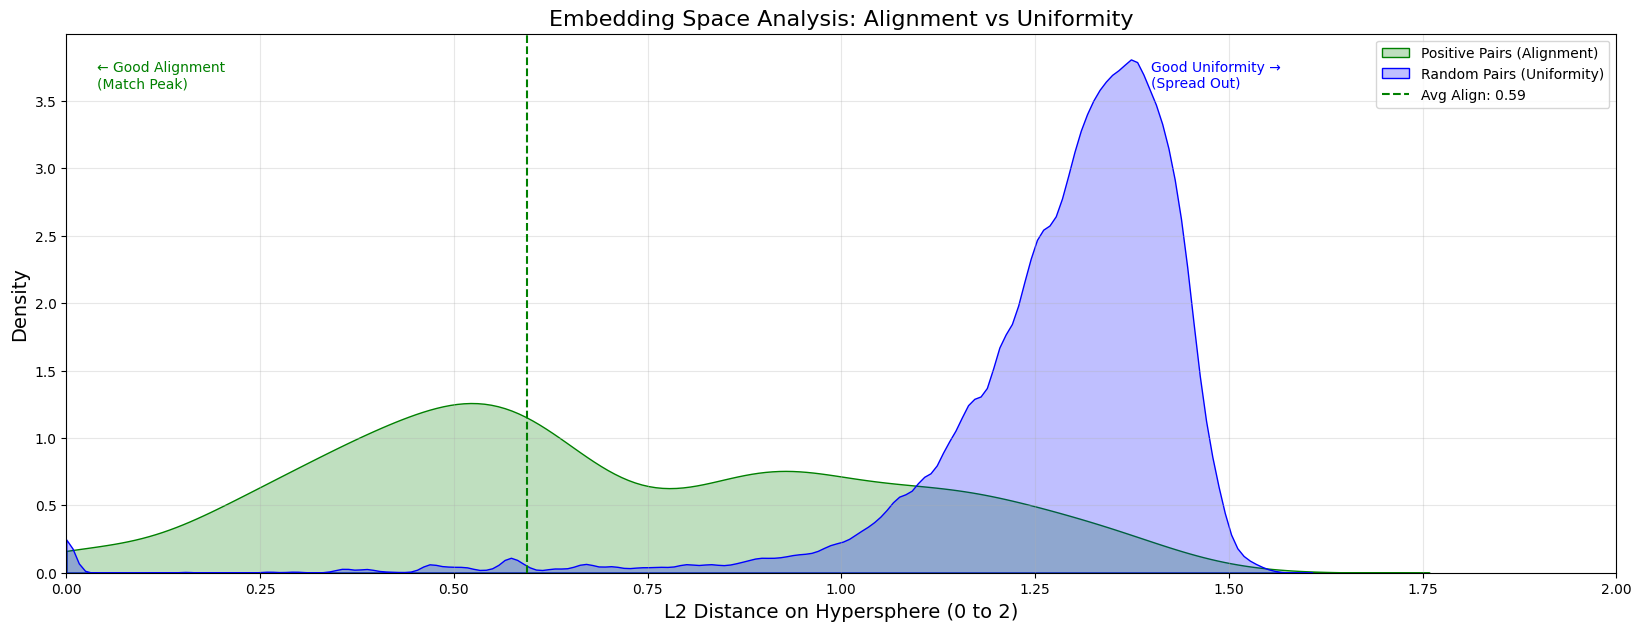

: 

In [ ]:
# --- 5. RUN ---
evaluate_metrics(args)